# Project Writeup - Mancala
By: Luca Chaia and Adara Noble

## Overview
- A working mancala engine created from the `Mancala` class from HW #6
- A light simulation system that runs **random vs. AI** for `N` games, accumulates statistics and displays the results. Supports:
    -  **Random vs. Random**
    -  **Random vs. Mini-Max**
    -  **Random vs. Alpha-Beta** 
- Deterministic runs supported via a seed setter

## Libraries and Frameworks Used

In [2]:
import random

We use `random` in our random move generator as well as for setting seeds

In [3]:
import numpy as np

We use `numpy` to store and manipulate our data using their array operators

In [4]:
from dataclasses import dataclass, field

We use `dataclass` to track and display the stats of the simulated matches

In [5]:
import time

We use the `time` package to track how long it takes to run matches

In [6]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

We use `matplotlib.pyplot` for plotting the win percentage of our alpha-beta AI. `PercentFormatter` helps us format our results as percentages.

In [7]:
import sys #sys.builtin_module_names
!{sys.executable} -m pip install numpy
#https://stackoverflow.com/questions/48754352/python-package-not-found-in-jupyter-even-after-running-pip-install?rq=3

## The Mancala Engine

In [8]:
class Mancala:
    def __init__(self, pits_per_player=6, stones_per_pit = 4, quiet=False, mancalaRule = True):
        """
        The constructor for the Mancala class defines several instance variables:

        pits_per_player: This variable stores the number of pits each player has.
        stones_per_pit: It represents the number of stones each pit contains at the start of any game.
        board: This data structure is responsible for managing the Mancala board.
        current_player: This variable takes the value 1 or 2, as it's a two-player game, indicating which player's turn it is.
        moves: This is a list used to store the moves made by each player. It's structured in the format (current_player, chosen_pit).
        p1_pits_index: A list containing two elements representing the start and end indices of player 1's pits in the board data structure.
        p2_pits_index: Similar to p1_pits_index, it contains the start and end indices for player 2's pits on the board.
        p1_mancala_index and p2_mancala_index: These variables hold the indices of the Mancala pits on the board for players 1 and 2, respectively.
        """
        self.pits_per_player = pits_per_player
        self.board = [stones_per_pit] * ((pits_per_player+1) * 2)  # Initialize each pit with stones_per_pit number of stones 
        self.current_player = 1 # start with player 1
        self.moves = [] 
        self.p1_pits_index = [0, self.pits_per_player-1] 
        self.p1_mancala_index = self.pits_per_player
        self.p2_pits_index = [self.pits_per_player+1, len(self.board)-1-1] 
        self.p2_mancala_index = len(self.board)-1
        self.quiet = quiet
        self._print = print if not quiet else (lambda *a, **k: None)
        self._rand = random
        self.mancalaRule = mancalaRule #checks if we're following the mancalaRule
        
        
        # Zeroing the Mancala for both players
        self.board[self.p1_mancala_index] = 0
        self.board[self.p2_mancala_index] = 0

        self.winner = 0 # stores the winner for easy access later

    
    def display_board(self):
        """
        Displays the board in a user-friendly format
        """
        player_1_pits = self.board[self.p1_pits_index[0]: self.p1_pits_index[1]+1]
        player_1_mancala = self.board[self.p1_mancala_index]
        player_2_pits = self.board[self.p2_pits_index[0]: self.p2_pits_index[1]+1]
        player_2_mancala = self.board[self.p2_mancala_index]

        print('P1               P2')
        print('     ____{}____     '.format(player_2_mancala))
        for i in range(self.pits_per_player):
            if i == self.pits_per_player - 1:
                print('{} -> |_{}_|_{}_| <- {}'.format(i+1, player_1_pits[i], 
                        player_2_pits[-(i+1)], self.pits_per_player - i))
            else:    
                print('{} -> | {} | {} | <- {}'.format(i+1, player_1_pits[i], 
                        player_2_pits[-(i+1)], self.pits_per_player - i))
            
        print('         {}         '.format(player_1_mancala))
        turn = 'P1' if self.current_player == 1 else 'P2'
        print('Turn: ' + turn)

    
    def valid_move(self, pit):
        """
        Function to check if the pit chosen by the current_player is a valid move.
        """
        pit -= 1 #accounts for 1-indexing

        #populates valid_range with the indices of pits belonging to the current_player
        if self.current_player == 1:
            valid_range = range(self.p1_pits_index[0], self.p1_pits_index[1] + 1)
        else:
            valid_range = range(self.p2_pits_index[0], self.p2_pits_index[1] + 1)

        #checks whether the selected pit is within the range of pits belonging to the current_player
        if pit < len(valid_range):
            #creates a list with all the valid ranges (converted from range()) then grabs the value at index 'pit'
            # aka: converts the pit number to match the pit's index in the board
            pit_index = list(valid_range)[pit]
        else: 
            print("Issue is with range")
            return False
        
        if self.board[pit_index] == 0: #checks if the pit is empty at the (determined to be valid) index
            print("Problem is with stones")
            return False

        return True

    
    def random_move_generator(self):
        """
        Function to generate random valid moves with non-empty pits for the random player
        """
        valid_pits = []
        if self.current_player == 1:
            start, end = self.p1_pits_index #unpacks p1's pit indices
        else:
            start, end = self.p2_pits_index #unpacks p2's pit indices

        for i in range(start, end + 1): #generates indices of current player's pits
            if self.board[i] > 0: #checks whether each pit is empty
                valid_pits.append(i - start + 1) #if not empty, pit index gets added to the list of valid indices

        if not valid_pits: #if this happens, there is an issue with the win calculation or with this generator
            return None
        
        return self._rand.choice(valid_pits) #randomly chooses a pit (move) from the list of valid moves

    
    def play(self, pit):
        """
        This function simulates a single move made by a specific player using their selected pit. It primarily performs three tasks:
        1. It checks if the chosen pit is a valid move for the current player. If not, it prints "INVALID MOVE" and takes no action.
        2. It verifies if the game board has already reached a winning state. If so, it prints "GAME OVER" and takes no further action.
        3. After passing the above two checks, it proceeds to distribute the stones according to the specified Mancala rules.

        Finally, the function then switches the current player, allowing the other player to take their turn.
        """
        
        if not self.valid_move(pit): #checks if the move is valid 
            print(f"INVALID MOVE: Pit {pit} by Player {self.current_player}")
            return self.board

        if self.winning_eval(): #checks to see if the game has already been won
            print("GAME OVER")
            return self.board

        pit -= 1 #accounts for 1-indexing

        #converts the pit number to match the pit's index in the board
        if self.current_player == 1:
            pit_index = self.p1_pits_index[0] + pit
        else:
            pit_index = self.p2_pits_index[0] + pit

        stones = self.board[pit_index] #grabs the number of stones in the pit 
        self.board[pit_index] = 0 #empties the pit
        index = pit_index #initializes the iterable

        while stones > 0:
            index = (index + 1) % len(self.board) #if we're past the bounds of the board (which translates
            # to index equaling the lenth of the board), our index is set to the start of the list

            #ensures that you don't place stones in the other player's mancala
            if self.current_player == 1 and index == self.p2_mancala_index:
                continue
            if self.current_player == 2 and index == self.p1_mancala_index:
                continue

            self.board[index] += 1 #adds a stone to the current pit
            stones -= 1 #removes a stone from our 'hand'

        #implements the 'if a player's last stone lands in an empty pit on their side of the board, take that stone
        # and all the stones in the opposite pit (on the other player's side) and put them into your own mancala' rule
        if self.current_player == 1:
            #checks that the final pit is on player 1's side, and that the pit was empty (and now has 1 stone)
            if index in range(self.p1_pits_index[0], self.p1_pits_index[1] + 1) and self.board[index] == 1:
                opposite_index = self.p2_pits_index[1] - (index - self.p1_pits_index[0])
                #calculates P2's index
                captured = self.board[opposite_index]
                #places the stones into P1's mancala
                self.board[self.p1_mancala_index] += captured + 1
                self.board[index] = 0
                self.board[opposite_index] = 0
        else:
            #checks that the final pit is on player 2's side, and that the pit was empty (and now has 1 stone)
            if index in range(self.p2_pits_index[0], self.p2_pits_index[1] + 1) and self.board[index] == 1:
                opposite_index = self.p1_pits_index[1] - (index - self.p2_pits_index[0])
                #calculates P1's index
                captured = self.board[opposite_index]
                #places the stones into P2's mancala
                self.board[self.p2_mancala_index] += captured + 1
                self.board[index] = 0
                self.board[opposite_index] = 0

        #adds the move to 'history'
        self.moves.append((self.current_player, pit + 1))

        #implements the 'if your final stone was dropped into your mancala, take another turn, otherwise switch players' rule
        if not self.mancalaRule or ((self.current_player == 1 and index != self.p1_mancala_index) or (
                self.current_player == 2 and index != self.p2_mancala_index)):
            self.current_player = 2 if self.current_player == 1 else 1
        #else:
        #    print(f"Mancala Rule, player {self.current_player}, pit {index}")

        #skips the previously established rule, swaps players every turn
        #self.current_player = 2 if self.current_player == 1 else 1
        
        return self.board

    
    def winning_eval(self):
        """
        Function to verify if the game board has reached the winning state (if either of the players' pits are all empty)
        """
        #checks each pit in each players' side of the board to see if they're empty
        p1_side_empty = all(stone == 0 for stone in self.board[self.p1_pits_index[0]:self.p1_pits_index[1] + 1])
        p2_side_empty = all(stone == 0 for stone in self.board[self.p2_pits_index[0]:self.p2_pits_index[1] + 1])

        
        if p1_side_empty or p2_side_empty: # win condition met
            #adds the sum of all stones left within each players' pit to their respective mancalas
            self.board[self.p1_mancala_index] += sum(self.board[self.p1_pits_index[0]:self.p1_pits_index[1] + 1])
            self.board[self.p2_mancala_index] += sum(self.board[self.p2_pits_index[0]:self.p2_pits_index[1] + 1])
            #empties each player's pits
            for i in range(self.p1_pits_index[0], self.p1_pits_index[1] + 1):
                self.board[i] = 0
            for i in range(self.p2_pits_index[0], self.p2_pits_index[1] + 1):
                self.board[i] = 0

            #checks who won (has more stones in mancala)
            if self.board[self.p1_mancala_index] > self.board[self.p2_mancala_index]:
                self.winner = 1 # winner is player 1
                self._print("Player 1 wins!")
            elif self.board[self.p1_mancala_index] < self.board[self.p2_mancala_index]:
                self.winner = 2 # winner is player 2
                self._print("Player 2 wins!")
            else:
                #print("It’s a tie!")
                pass
            return True
        return False

## Our Utility Functions

We have tested various heuristics to serve as utility functions. Each one is its own function which is then stored in our `utilityEQ` dictionary. This makes it easy to implement and test new utility functions, as all it requires is changing a single parameter in our `run_matches` function.

We started with `util_mancala_stones(ai, board)`, which is the recommended starting function as described in the Course Project Plan. It calculates the difference between the stones in player 2's mancala and player 1's. Maximizing the value of this function means maximizing the stones in player 2's mancala compared to player 1's, which is not a bad strategy to employ.

We then added `util_test(ai, board)` which has a constant utility, and is only used for debugging.

Lastly, we experimented with creating our own utility function. The idea is to check the total differences in stones between the two players. This is our `util_stones_per_side` function. However, we found that it tends to underperform compared to our initial utility function. Therefore, we will be using our `util_mancala_stones` function for testing purposes.

In [9]:
def util_mancala_stones(ai, board):
    """
    Simple heuristic: difference in mancala stones (P2 - P1),
    Assumes AI is always player 2.
    """
    return board[ai.game.p2_mancala_index] - board[ai.game.p1_mancala_index]

def util_test(ai, board):
    # Just a constant utility for debugging
    return 1

def util_stones_per_side(ai, board):
    """
    Checks the difference in stones between the pits on the AI's side and those on the player's
    """
    p1_stones = sum(board[ai.game.p1_pits_index[0]:ai.game.p1_pits_index[1] + 1])
    p2_stones = sum(board[ai.game.p2_pits_index[0]:ai.game.p2_pits_index[1] + 1])
    return p2_stones - p1_stones


utilityEQ = {
    "Mancala Stones": util_mancala_stones,
    "Test":           util_test,
    "Stones per Side": util_stones_per_side,
}

## The AI - Minimax and AlphaBeta

Our AI player is implemented in the `AI` class. The class executes three main ideas:
1. A pluggable **utility function** that evaluates board positions.
2. Two search algorithms, **minimax** and **alpha-beta pruning**, that explore the game tree up to a fixed depth in plies.
3.  Its own `play` function that simulated moves on a copy of the Mancala board. While we do keep the `Mancala` class to keep track of the actual board positions, we use the `play` function to generate future board states.

### Overall design and initialization

The constructor
```
class AI:
    def __init__(self, game, plies, utility = "Mancala Stones"):
        ...
```
takes a `Mancala` instance, a search depth `plies`, and the name of the utility function to use. We store the game object so the AI can reuse the same indexing scheme (`p1_pits_index`, `p2_mancala_index`, etc.) and board layout as the engine. The `utility` string is looked up in the `utilityEQ` dictionary to get the actual function object.

We also keep a `nodes_expanded` counter and a helper `_touchNode()` method. Every recursive call to a minimax or alpha-beta routine calls `_touchNode()`, which gives us a rough measure of how much of the game tree was explored for a given move or match, which helps us compare plain minimax vs. alpha-beta pruning and testing different ply depths.  
  
Lastly, we added **two transposition tables**, one for `abMax` and one for `abMin`. The first time we tried to run alpha-beta at 10 plies *with the continuation rule*, due to hardware limitations it took **over an hour**, and didn't even finish running. We had to kill the kernel. Our alpha-beta is exploring a search tree of board states. However, different sequences of moves can lead to the same board configuration at the same time, especially with the continuation rule. Pure recursion treats each path as unique and recomputes the entire subtree from scratch, even if it's seen that position before. So, we decided to cache the solutions. This led to a significant speed up.

### Terminal states and utility evaluation

The core evaluation logic is found in the `evalUtility` function. This method does two things:
1. It first checks whether the position is **terminal** using `self.winning_eval(board)`. We define a terminal state as either side having only empty pits. In that case, we simulate the final scoring by adding each side's remaining pit stones into their respective mancalas. If the position is terminal, we return:
    - $\infty$ if the AI (Player 2) wins,
    - $-\infty$ if Player 1 wins,
    - $0$ in case of a tie  
>Using $\pm\infty$ at terminal nodes tells the search that actual wins and losses are much more important than any heuristic estimate.  

2. If the state is **not** terminal, `evalUtility` calls the chosen utility function via
```
return self.utility_func(self, board)
```
This separation between terminal handling and heuristic evaluation made it straightforward to swap utility functions during testing.

### Minimax search

Our basic decision procedure is minimax, implemented via two mutually recursive methods:
- `minimaxMax(self, board, currPly=0)` - AI's turn (Player 2, maximizing the utility for Player 2).
- `minimaxMin(self, board, currPly=0)` - opponent's turn (Player 1, minimizing the utility for Player 2)

Both functions follow the algorithms described in our _AIMA_ textbook:
#### 1. Base case:  
If `currPly == self.plies` or `winning_eval(board)` is true, we stop expanding and return (`evalUtility(board), None)`
#### 2. Recursive case: 
We increment the ply counter and iterate over all **legal moves** for the current player. So for `minimaxMax`, we iterate over pits in `self.game.p2_pits_index`; for `minimaxMin`, over `self.game.p1_pits_index`. We skip pits with zero stones.  
  
For each candidate pit, we compute whether this move triggers the `continuation rule` for that player, implemented as:
   ```
   mancalaRule = (pit + board[pit]) % len(board) == self.game.pX_mancala_index
   ```
   This checks whether the last stone would land in that player's own mancala. If the continuation rule is *not* triggered, we switch turns and call the opposite function with the incremented ply:  
   - From `minimaxMax` to `minimaxMin`
   - From `minimaxMin` to `minimaxMax`  
If the continuation rule *is* triggered, we **do not advance the ply depth** for the extra move. Instead, we recurse back into the same player's function with `currPly - 1`. The idea is that a free extra turn should not consume our limited ply budget.

For each move, we keep track of the best `(value, pit)` tuple according to whether we are maximizing or minimizing. At the top level, `AIMove(board)` simply calls `minimaxMax(board[:])` and then converts the chosen pit index into the one-based indexing the `Mancala` engine expects.

### Alpha-beta pruning

The alpha-beta version mirrors the structure of minimax, but adds pruning. Like for minimax, we have `abMax` which Player 2 uses to maximize their utility, and `abMin`, which Player 1 uses and which minimizes the utility for Player 2.  

Each function: 
1. Checks the same base case (`currPly == self.plies` or terminal board) and returns `evalUtility` if so.
2. Iterates over legal moves on the appropriate side, applying `self.play` to generate child states.
3. Uses the same **continuation rule logic** as minimax, where we recurse into the same function at the same effective depth for the extra turn. Otherwise, we alternate to the other function and advance the ply.  

For `abMax`, we maintaing a running best `(value, pit)`, where `value` starts at $-\infty$. After evaluating each child:
- If the new value is greater than the current best, we update it and possibly increase `alpha`.
- If `value > beta`, we can cut off the remaining moves because the minimizing player would never allow us to reach a position that good. Of course, we'll see that a random opponent will frequently let us make moves that good, but we can simply reevaluate from this new position.
`abMin` is symmetric, starting from $infty$, updating `beta` and pruning when `value < alpha`.  
  
We also handle the edge case where a player has no legal moves before reaching the official terminal condition. In that case, we fall back to evaluating the board once. We treat the board as effectively terminal for the purposes of this search branch.  
  
The move returned by `pruningMove(board)` is obtained by calling `abMax` at the root and converting the resulting pit index in the same way that `AIMove` does for minimax.

### Continuation rule and evaluation changes

One of the extra-credit components of the project was to fully implement the continuation rule. Our `Mancala` engine itself initially omits this rule, per the base project instructions, but we later added it back in, implemented as:
```
if (self.current_player == 1 and index != self.p1_mancala_index) or (self.current_player == 2 and index != self.p2_mancala_index):
    self.current_player = 2 if self.current_player == 1 else 1
```
The continuation rule has two important effects on our AI implementation:
1. **Game tree shape**: positions where a player can "loop" extra moves into their own mancala become more valuable because a single move can expand into a sequence of winning moves. Our `mancalaRule` check and the "recurse into the same player at the same depth" logic captures this.
2. **Utility behavior**: with the continuation rule, heuristics that only track raw pit stones (like our `util_stones_per_side`) can overvalue scattered stones, even if those stones were poorly positioned. Because of our limited search depth, the AI must rely on the heuristic to judge intermediate positions. A large number of loose stones looks very good to `util_stones_per_side`, but these stones are not always "bankable": they might be vulnerable to capture or arranged so that they do not produce extra turns under the continuation rule. In contrast, `util_mancala_stones` remains closely tied to the final scoring, so it behaved more consistently and almost always led to a win even at relatively shallow ply depths.

In [10]:
class AI:
    def __init__(self, game, plies, utility = "Mancala Stones", mancalaRule=True):
        self.game = game #this is so we don't have to keep adding and removing variables if later utilities require different things
        self.plies = plies
        self.mancalaRule = mancalaRule
        try:
            self.utility_func = utilityEQ[utility]
        except KeyError:
            raise ValueError(f"Unknown utility function: {utility}")
        self.nodes_expanded = 0

        #transposition tables for max and min-nodes
        #key: (board_tuple, currPly)
        #value: 
        self.tt_max = {}
        self.tt_min = {}

    def _touchNode(self):
        self.nodes_expanded += 1

    def evalUtility(self, board):
        p1_stones = sum(board[self.game.p1_pits_index[0]:self.game.p1_pits_index[1] + 1])
        p2_stones = sum(board[self.game.p2_pits_index[0]:self.game.p2_pits_index[1] + 1])
        #checks if this state is a win state. If so, checks whether the AI is the winner, or the player.
        #Returns infinity if a win for the AI (this is the ultimate goal, after all)
        #or negative infinity if it's a win for the player. We want to avoid that at all costs.
        if self.winning_eval(board):
            p1_score = board[self.game.p1_mancala_index] + p1_stones
            p2_score = board[self.game.p2_mancala_index] + p2_stones
            if p2_score < p1_score:
                return -np.inf
            elif p2_score > p1_score:
                return np.inf
            else:
                return 0
        #if the board is not a win condition, we use our utility function (defined at AI initialization)
        else:
            return self.utility_func(self, board)

    #Minimax move function
    def AIMove(self, board):
        #converts the pit to match what the Mancala engine expects
        _, pit = self.minimaxMax(board[:])
        return (pit - self.game.p2_pits_index[0] + 1)

    #Alpha-Beta move function
    def pruningMove(self, board):
        #clear TT for this search
        self.tt_max.clear()
        self.tt_min.clear()

        
        alpha = -np.inf
        beta =  np.inf
        _, pit = self.abMax(board[:], alpha, beta)
        if pit is None:
            return None
        return (pit - self.game.p2_pits_index[0] + 1)

    #Minimax eval functions
    def minimaxMin(self, board, currPly = 0):
        self._touchNode() #counts this node
        
        if currPly == self.plies or self.winning_eval(board):
            return (self.evalUtility(board), None)

        best = (np.inf, None)
        currPly += 1
    
        for pit in range(self.game.p1_pits_index[0], self.game.p1_pits_index[1] + 1):
            if board[pit] > 0:
                mancalaRule = (pit + board[pit])%len(board) == self.game.p1_mancala_index
                newBoard = self.play(board[:], pit)
                val, _ = self.minimaxMin(newBoard, currPly-1) if (mancalaRule and self.mancalaRule) else self.minimaxMax(newBoard, currPly)
                if val <= best[0]:
                    best = (val, pit)
    
        return best

    def minimaxMax(self, board, currPly = 0):
        self._touchNode() #counts this node

        
        if currPly == self.plies or self.winning_eval(board):
            return (self.evalUtility(board), None)

        best = (-np.inf, None)
        currPly += 1
    
        for pit in range(self.game.p2_pits_index[0], self.game.p2_pits_index[1] + 1):
            if board[pit] > 0:
                mancalaRule = (pit + board[pit])%len(board) == self.game.p2_mancala_index
                newBoard = self.play(board[:], pit)
                val, _ = self.minimaxMax(newBoard, currPly-1) if (mancalaRule and self.mancalaRule) else self.minimaxMin(newBoard, currPly)
                if val >= best[0]:
                    best = (val, pit)
    
        return best

    #Alpha-Beta eval functions
    def abMin(self, board, alpha, beta, currPly = 0):
        self._touchNode() #counts this node

        key = (tuple(board), currPly)
        #look up in min-table
        if key in self.tt_min:
            return self.tt_min[key]
        
        if currPly == self.plies or self.winning_eval(board):
            return (self.evalUtility(board), None)

        currPly += 1
        moves = []
        value = (np.inf, None)
        has_move = False
        
        for pit in range( self.game.p1_pits_index[0], self.game.p1_pits_index[1] + 1 ):
            if board[pit] > 0: #checks validity of move
                has_move = True
                mancalaRule = (pit + board[pit])%len(board) == self.game.p1_mancala_index
                newBoard = self.play(board[:], pit)
                tmp = (self.abMin(newBoard, alpha, beta, currPly-1)[0], pit) if (mancalaRule and self.mancalaRule) else (
                    self.abMax(newBoard, alpha, beta, currPly)[0], pit)
                value = tmp if tmp[0] <= value[0] else value
                if value[0] < alpha: 
                    self.tt_min[key] = value #store before cutoff
                    return value
                else:
                    beta = min(value[0], beta) # if tmp[0] <= beta else beta
    
        if not has_move:
            return (self.evalUtility(board), None)
        else:
            self.tt_min[key] = value
            return value

    def abMax(self, board, alpha, beta, currPly = 0):
        self._touchNode() #counts this node

        key = (tuple(board), currPly)
        #look up in max table
        if key in self.tt_max:
            return self.tt_max[key]
        
        if currPly == self.plies or self.winning_eval(board):
            return (self.evalUtility(board), None)

        currPly += 1
        moves = []
        value = (-np.inf, None)
        has_move = False
        
        for pit in range( self.game.p2_pits_index[0], self.game.p2_pits_index[1] + 1 ):
            if board[pit] > 0:
                has_move = True
                mancalaRule = (pit + board[pit])%len(board) == self.game.p2_mancala_index
                newBoard = self.play(board[:], pit)
                tmp = (self.abMax(newBoard, alpha, beta, currPly-1)[0], pit) if (mancalaRule and self.mancalaRule) else (
                    self.abMin(newBoard, alpha, beta, currPly)[0], pit)
                value = tmp if tmp[0] >= value[0] else value
                if value[0] > beta: 
                    self.tt_max[key] = value
                    return value
                else:
                    alpha = tmp[0] if tmp[0] >= alpha else alpha
        
        if not has_move:
            return (self.evalUtility(board), None)
        else:
            self.tt_max[key] = value
            return value

    def winning_eval(self, board):
        p1_side_empty = all(stone == 0 for stone in board[self.game.p1_pits_index[0]:self.game.p1_pits_index[1] + 1])
        p2_side_empty = all(stone == 0 for stone in board[self.game.p2_pits_index[0]:self.game.p2_pits_index[1] + 1])
        if p1_side_empty or p2_side_empty: 
            return True
        return False

    def play(self, board, pit_index): 
        #determines the 'current player' based on the pit
        current_player = 1 if pit_index in range(self.game.p1_pits_index[0],self.game.p1_mancala_index + 1) else 2
        
        #a mostly exact copy of the play function from the game class
        stones = board[pit_index]
        board[pit_index] = 0 
        index = pit_index
        while stones > 0:
            index = (index + 1) % len(board)
            if (current_player == 1 and index == self.game.p2_mancala_index) or (current_player == 2 and index == self.game.p1_mancala_index):
                continue
            board[index] += 1
            stones -= 1
        if current_player == 1:
            if index in range(self.game.p1_pits_index[0], self.game.p1_pits_index[1] + 1) and board[index] == 1:
                opposite_index = self.game.p2_pits_index[1] - (index - self.game.p1_pits_index[0])
                captured = board[opposite_index]
                board[self.game.p1_mancala_index] += captured + 1
                board[index] = 0
                board[opposite_index] = 0
        else:
            if index in range(self.game.p2_pits_index[0], self.game.p2_pits_index[1] + 1) and board[index] == 1:
                opposite_index = self.game.p1_pits_index[1] - (index - self.game.p2_pits_index[0])
                captured = board[opposite_index]
                board[self.game.p2_mancala_index] += captured + 1
                board[index] = 0
                board[opposite_index] = 0
        
        return board



## Data structures used for statistics
### `PlayerStats`
Tracks results for one player (`p1` or `p2`)

In [11]:
@dataclass
class PlayerStats:
    wins: int = 0
    losses: int = 0
    ties: int = 0

### `MatchStats`
Holds both players and global counters

In [12]:
@dataclass
class MatchStats:
    p1: PlayerStats = field(default_factory=PlayerStats)
    p2: PlayerStats = field(default_factory=PlayerStats)
    turns_total: int = 0
    games: int = 0

### Simulation runner: `run_matches(...)`
**How it works:**
- Creates a fresh `Mancala` game each match with `quiet=True` by default (so the engine doesn’t spam prints during tests).

- Generates random valid moves for the current player until `winning_eval()` declares the game over.

- Counts turns by incrementing once per `play(...)`.

- Updates separate stats for Player 1 and Player 2 (wins, losses, ties).

- Has parameters that allow us to experiment with our AI:

    - `mancalaRule` must be set to true to implement the Mancala rule.
    - `alphabeta` must be set to true to use the alpha-beta pruning functions; otherwise, it will default to minimax.

Returns a small result bundle with:

- `stats` (typed counters),

- `avg_turns` (mean turns per game),

- `turns_per_game` (raw list in case we want to do further data analysis, like a histogram)

- `nodes_per_game` (the total expanded nodes)

- `avg_nodes_per_game` (the average of the expanded nodes in the simulation)

- `total_time_sec` (total time the simulation took to run in seconds)

- `avg_time_per_game_sec` (the average time it took to run a game in seconds)

- `utility_used` (the utility used)

**Determinism:** If a seed is provided, Python’s random is seeded, so repeated runs are reproducible.

**Quiet mode:** Passing `quiet=True` silences engine prints (via `self._print` inside ``Mancala).

In [18]:
def run_matches(num_games=100, 
                *, 
                utility = "Mancala Stones", 
                pits_per_player=6, 
                stones_per_pit=4, 
                quiet=True, 
                seed=None, 
                alphabeta=False, 
                plies=10,
                mancalaRule = False
               ):
    if seed is not None:
        random.seed(seed)

    stats = MatchStats()
    turns_per_game = []
    nodes_per_game = [] 

    start_time = time.time() #timing start
    
    for _ in range(num_games):
        game = Mancala(pits_per_player=pits_per_player, stones_per_pit=stones_per_pit, quiet=quiet, mancalaRule=mancalaRule)
        ai = AI(game, plies, utility, mancalaRule)
        move_func = ai.pruningMove if alphabeta else ai.AIMove
        turns = 0

        while not game.winning_eval():
            assert game.current_player == 1, f"Player should be 1, is currently {game.current_player}"
            pit = game.random_move_generator()
            if pit is None:
                game._print("Error")
                break
            index = pit + game.p1_pits_index[0] - 1
            game.play(pit)
            if game.current_player == 1:
                continue
            turns += 1

            while game.current_player == 2 and not game.winning_eval():
                pit = move_func(game.board[:])
                index = pit + game.p2_pits_index[0] - 1
                if pit is None:
                    break
                game.play(pit)

        # record nodes this AI used in this game
        nodes_per_game.append(ai.nodes_expanded)

        # update stats
        if game.winner == 1:
            stats.p1.wins += 1
            stats.p2.losses += 1
        elif game.winner == 2:
            stats.p2.wins += 1
            stats.p1.losses += 1
        else:
            stats.p1.ties += 1
            stats.p2.ties += 1

        stats.turns_total += turns
        stats.games += 1
        turns_per_game.append(turns)

    total_time = time.time() - start_time #timing end

    # result bundle
    return {
        "stats": stats,
        "turns_per_game": turns_per_game,
        "avg_turns": float(np.mean(turns_per_game)) if turns_per_game else 0.0,
        "nodes_per_game": nodes_per_game,
        "avg_nodes_per_game": float(np.mean(nodes_per_game)) if nodes_per_game else 0.0,
        "total_time_sec": total_time,
        "avg_time_per_game_sec": (total_time / num_games) if num_games > 0 else 0.0,
        "utility_used": utility,
    }

### Report printing helper: `print_stats(result)`
- Prints **win/loss/tie** pct per player
- Also includes the number of nodes expanded and the average time it took to run a game.
We'll be using this for all of the matches that utilize the AI class, but not our random vs random matches

In [19]:
def print_stats(result):
    s = result["stats"]
    n = s.games or 1  # avoid div by zero
    p1_win_pct = 100 * s.p1.wins / n
    p2_win_pct = 100 * s.p2.wins / n
    tie_pct   = 100 * s.p1.ties / n  # same as p2.ties
    avg_turns = result["avg_turns"]
    avg_nodes_per_game = result["avg_nodes_per_game"]
    avg_time_per_game_sec = result["avg_time_per_game_sec"]
    utility_used = result["utility_used"]

    print(f"Player 1 — Won: {s.p1.wins} ({p1_win_pct:.1f}%), "
          f"Lost: {s.p1.losses} ({100 * s.p1.losses / n:.1f}%), ")

    print(f"Player 2 — Won: {s.p2.wins} ({p2_win_pct:.1f}%), "
          f"Lost: {s.p2.losses} ({100 * s.p2.losses / n:.1f}%), ")
    print(f"Ties: {s.p2.ties} ({tie_pct:.1f}%)")
    print(f"Utility function used: {utility_used}")
    print(f"Average turns per game: {avg_turns:.2f}")
    print(f"Average nodes expanded per game: {avg_nodes_per_game:.2f}")
    print(f"Average time per game in seconds: {avg_time_per_game_sec:.2f}")


## Test results

### Random vs. Random

In [20]:
num_games = 100
p1_wins = p2_wins = ties = 0

for _ in range(num_games):
    game = Mancala(quiet=True)

    while not game.winning_eval():
        pit = game.random_move_generator()
        if pit is None:
            break
        game.play(pit)

    if game.winner == 1:
        p1_wins += 1
    elif game.winner == 2:
        p2_wins += 1
    else:
        ties += 1

print("P1 wins:", p1_wins)
print("P2 wins:", p2_wins)
print("Ties:", ties)
print("P1 - P2 wins:", p1_wins - p2_wins)

P1 wins: 48
P2 wins: 45
Ties: 7
P1 - P2 wins: 3


Although we do have a function to run games, it'd be like using a Ferrari to pick up groceries in this case. A simple for loop does the job much better. It depends on the run, but usually we see P1 have a slight advantage over P2.

### Mini-Max

#### At a depth of 5 plies

In [21]:
res_minimax_5_plies = run_matches(num_games=100, utility = "Mancala Stones", alphabeta=False, plies=5, seed=42, mancalaRule=False)
print_stats(res_minimax_5_plies)

Player 1 — Won: 0 (0.0%), Lost: 100 (100.0%), 
Player 2 — Won: 100 (100.0%), Lost: 0 (0.0%), 
Ties: 0 (0.0%)
Utility function used: Mancala Stones
Average turns per game: 16.94
Average nodes expanded per game: 34951.67
Average time per game in seconds: 0.04


Our results indicate that even at a relatively shallow depth, minimax is **much** better than a random player. It's not like we have chosen the best possible utility function either, but we're consistently winning almost every match. We're also setting a seed for this particular run to be able to compare results to our 5-ply alpha-beta games.

### Alpha-Beta

#### At a depth of 5 plies

In [23]:
res_ab_5_plies = run_matches(num_games=100, utility = "Mancala Stones", alphabeta=True, plies=5, seed=42, mancalaRule=False)
print_stats(res_ab_5_plies)

Player 1 — Won: 0 (0.0%), Lost: 100 (100.0%), 
Player 2 — Won: 100 (100.0%), Lost: 0 (0.0%), 
Ties: 0 (0.0%)
Utility function used: Mancala Stones
Average turns per game: 16.94
Average nodes expanded per game: 17754.16
Average time per game in seconds: 0.03


We see that our alpha-beta AI expands far fewer nodes than our minimax AI. Since they had the same win rate and nearly the same number of moves, we can conclude that they're always making nearly identical moves, if not wholly identical, which makes sense because they're using the same utility function. Both are trying to maximize the value of that utility function for Player 2. Of course, there could be cases where they could differ. Once alpha-beta finds the best move, it could prune a branch with an equally good utility function evaluation. To amend this, we are checking that `value[0]` is strictly greater than `alpha` or less than `beta`, depending on whether we are utilizing `abMin` or `abMax`. Therefore, the functions should use the same tie-breaking logic of updating to the last pit that yields the highest utility function value. Our transposition tables can explain the slight discrepancy we see. We're caching cut-off values and reusing them, which no longer guarantees that they will be identical. However, it was a much-needed speed-up. When we attempted to run alpha-beta at 5 plies previously, we expanded over 180000 nodes, meaning we avoided expanding solved nodes 40000 times.

#### At a depth of 10 plies

In [27]:
res_ab_10_plies = run_matches(num_games=100, utility = "Mancala Stones", alphabeta=True, plies=10, mancalaRule=False)
print_stats(res_ab_10_plies)

Player 1 — Won: 1 (1.0%), Lost: 99 (99.0%), 
Player 2 — Won: 99 (99.0%), Lost: 1 (1.0%), 
Ties: 0 (0.0%)
Utility function used: Mancala Stones
Average turns per game: 15.18
Average nodes expanded per game: 6427658.77
Average time per game in seconds: 9.75


We see that we're expanding way more nodes. Thanks to our transposition table we managed to make the cost of each game relatively cheap. Even so, in this context relatively cheap means over 6 million nodes per game.

#### Plotting our alpha-beta AI winrate

In [25]:
# getting win pct for 2 plies
res_ab_2_plies = run_matches(num_games=100, utility = "Mancala Stones", alphabeta=True, plies=2)

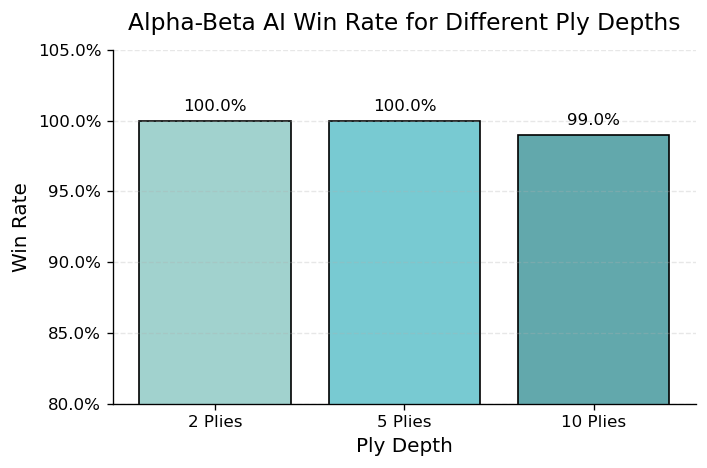

In [28]:
# data
res_ab_2_plies_stats = res_ab_2_plies["stats"]
res_ab_5_plies_stats = res_ab_5_plies["stats"]
res_ab_10_plies_stats = res_ab_10_plies["stats"]

ply_depth = ["2 Plies", "5 Plies", "10 Plies"]
win_pct = [res_ab_2_plies_stats.p2.wins, res_ab_5_plies_stats.p2.wins, res_ab_10_plies_stats.p2.wins]

# create figure and axis
fig, ax = plt.subplots(figsize=(6, 4), dpi=120)

# making the colors look prettier
colors = ["#A1D2CE", "#78CAD2", "#62A8AC"] 
bars = ax.bar(ply_depth, win_pct, color=colors, edgecolor="black", linewidth=1)


# titles and labels
ax.set_title("Alpha-Beta AI Win Rate for Different Ply Depths", fontsize=14, pad=12)
ax.set_xlabel("Ply Depth", fontsize=12)
ax.set_ylabel("Win Rate", fontsize=12)

# y-axis: start at 80%, end at 105% for spacing
ax.set_ylim(80, 105)

# format y-axis as percentages (assuming win_pct is 0–100)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))

# light horizontal gridlines for readability
ax.grid(axis="y", linestyle="--", alpha=0.3)

# make the top and right borders disappear for a cleaner look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# add value labels on top of the bars
for bar, value in zip(bars, win_pct):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

100 games is a very finite sample, and not representative of the "true" performance of our AI. In fact, we actually use a seeded run at 5 plies to compare it to minimax. However, there is something to be said about diminishing returns the deeper the plies. In a match against a real player, one would have to look several moves ahead. However, in this case the player is playing completely random moves, sometimes picking the worst possible move, and in one instance picking near perfect moves to beat our 10-ply depth alpha-beta pruning AI. Against such an opponent, having even a basic strategy all but guarantees success, even if you are only looking two moves ahead.

#### Implementing the Mancala rule

Previously, we had tried to implement the Mancala rule for 100 games at 10 plies of alpha-beta. This was a two hour mistake. Python's GLI continues to crush our dreams, and Jupyter Notebook is also not helping. That being said, we can run one game, and compare that to the simulation we ran *without* the Mancala rule.

In [30]:
res_ab_mancala_rule_10_plies = run_matches(num_games=1, utility = "Mancala Stones", alphabeta=True, plies=10, mancalaRule=True)
print_stats(res_ab_mancala_rule_10_plies)

Player 1 — Won: 0 (0.0%), Lost: 1 (100.0%), 
Player 2 — Won: 1 (100.0%), Lost: 0 (0.0%), 
Ties: 0 (0.0%)
Utility function used: Mancala Stones
Average turns per game: 10.00
Average nodes expanded per game: 65788440.00
Average time per game in seconds: 105.99


We see that each individual game can take more than 10 times as long as without the Mancala Rule. This game seems to indicate that we were successful. However, the memory cost is too expensive to run repeated tests.   

Instead, if we apply the mancala rule at lower plies, we still get an extremely high win rate.

In [31]:
res_ab_mancala_rule_5_plies = run_matches(num_games=100, utility = "Mancala Stones", alphabeta=True, plies=5, mancalaRule=True)
print_stats(res_ab_mancala_rule_5_plies)

Player 1 — Won: 0 (0.0%), Lost: 100 (100.0%), 
Player 2 — Won: 100 (100.0%), Lost: 0 (0.0%), 
Ties: 0 (0.0%)
Utility function used: Mancala Stones
Average turns per game: 9.40
Average nodes expanded per game: 121577.25
Average time per game in seconds: 0.18


This simulation supports our claim that we successfully implemented the mancala rule, as we see that we are properly accounting for it.  
Unfortunately, unless we decide to rewrite the entire project in a language that supports multithreading, we will not be able to test this feature thoroughly. Compared to the 5-ply run without the mancala rule, this one expands almost ten times the nodes.